# Loading and Visualization

In this section, we illustrate how to load and visualize the pseudoPAGES2k dataset with `cfr`.

Required data to complete this tutorial:

- pseudoPAGES2k: [ppwn_SNRinf_rta.nc](https://github.com/fzhu2e/paper-pseudoPAGES2k/raw/main/data/ppwn_SNRinf_rta.nc)

In [1]:
%load_ext autoreload
%autoreload 2

%pip install cartopy
%pip install cfr
%pip install requests
%pip install nbformat>=4.2.0

import cfr
print(cfr.__version__)
import xarray as xr

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
2026.6.25.14


## Load the pseudoPAGES2k dataset with `xarray`

By default, we may load a netCDF file with `xarray` to have a check of the data structure:

In [ ]:
ds = xr.open_dataset('./data/ppwn_SNRinf_rta.nc', use_cftime=True)
ds

In [ ]:
ds['NAm_149']

We see that this netCDF file has multiple data variables named after **proxy IDs**.
Each variable comes with the below fundamental attributes:

- lat: the latitude of the site
- lon: the longitude of the site
- ptype: the proxy type
- dt: step of the time axis, i.e., temporal resolution
- time_name: name of the time axis
- time_unit: unit of the time axis
- value_name: unit of the value axis
- value_unit: unit of the value axis

With this certain format, the netCDF file is `cfr` ready.

## Load the pseudoPAEGS2k dataset with `cfr`

The `cfr.ProxyDatabase` class comes with a `.load_nc()` method that can help us load a proxy database from a netCDF file following the certain format shown above:

In [2]:
# load the pseudoPAGES2k database from a netCDF file

# load from a local copy
# pdb = cfr.ProxyDatabase().load_nc('./data/ppwn_SNRinf_rta.nc')

# load from the cloud
pdb = cfr.ProxyDatabase().fetch('pseudoPAGES2k/ppwn_SNRinf_rta')

## Visualize and check the pseudoPAGES2k dataset by using **proxy IDs** on an interactive map

One may ask "How do I know the proxy IDs?"

Once the netCDF file is loaded as a `cfr.ProxyDatabase`, we can easily visualize the dataset with the `.plot().

A `cfr.ProxyDatabase` object also comes with a `.plotly()` method that can help us check **proxy IDs** on an interactive map.
It will display an interactive map, and by hovering the mouse over each site marker, one may check the metadata of a specific site, including:

- pid (proxy ID)
- ptype
- lat
- lon

In [6]:
pdb.plotly()

We may also plot map along with the count of the records:

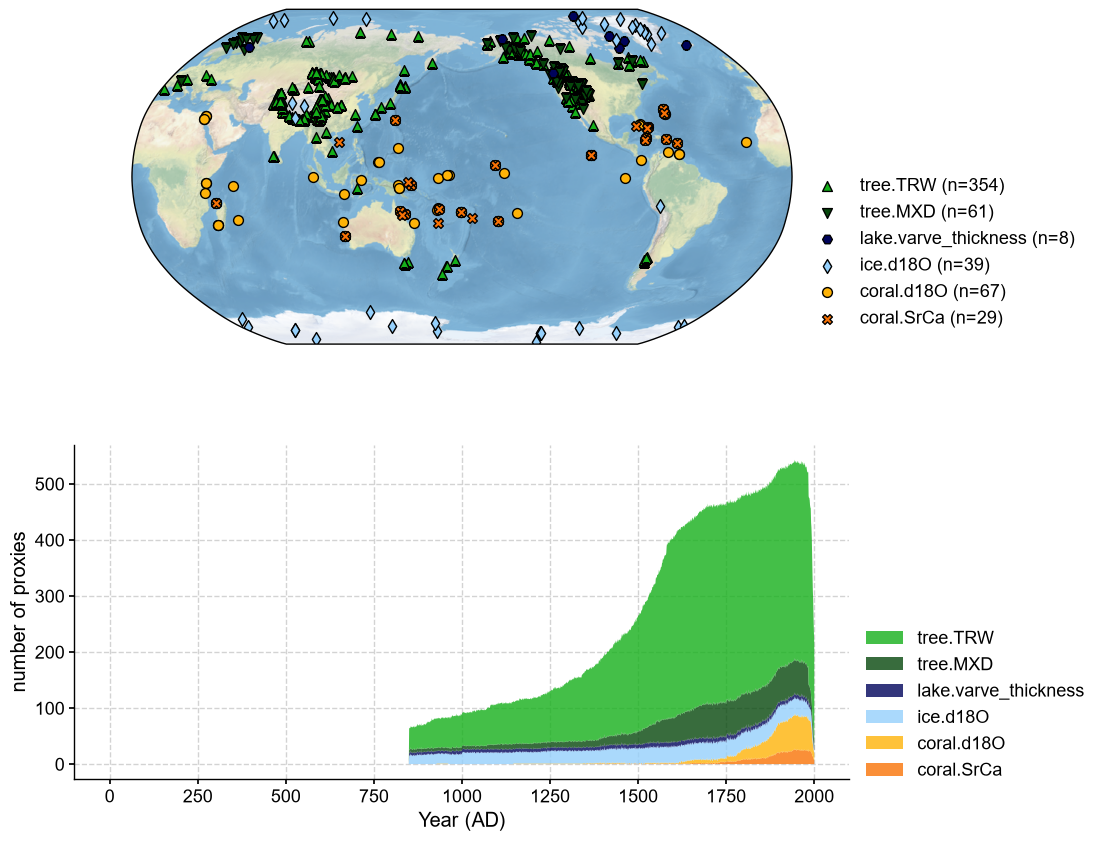

In [7]:
fig, ax = pdb.plot(plot_count=True)

Since the dataset starts from 850 AD, we may adjust the x-axis utilizing the `matplotlib` methods:

(800.0, 2000.0)

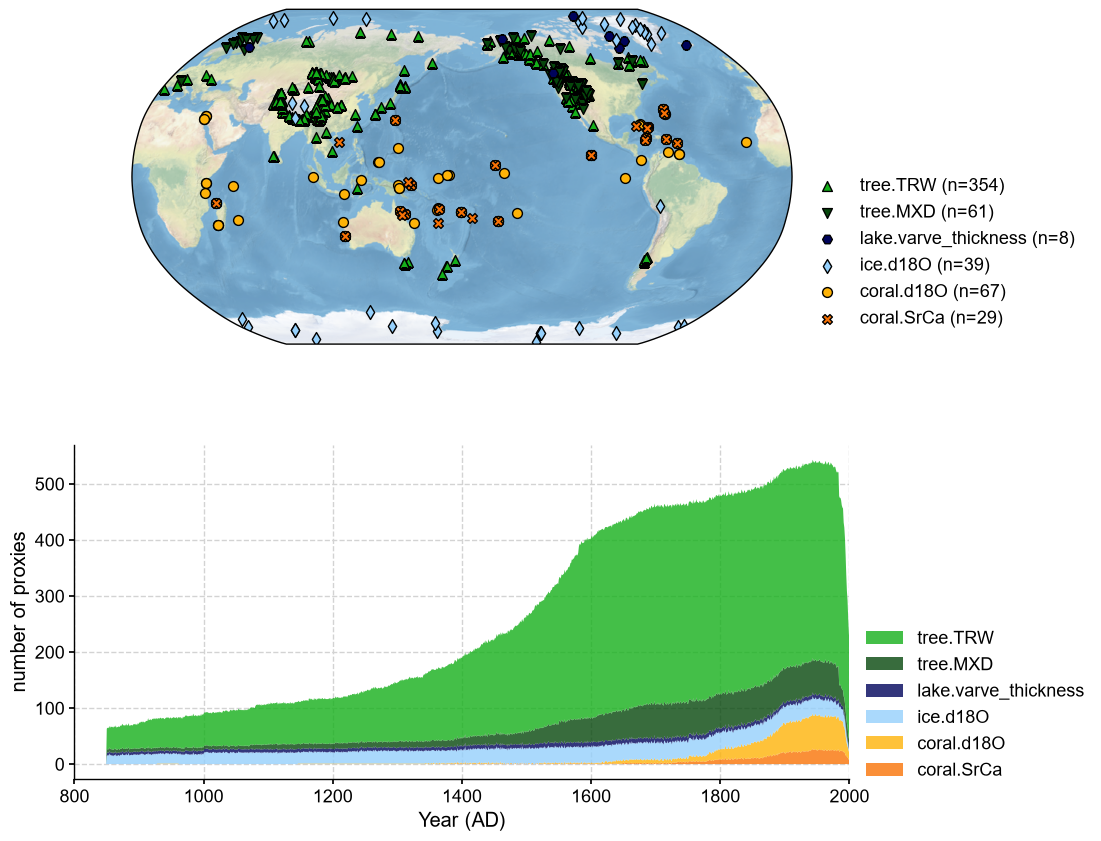

In [8]:
fig, ax = pdb.plot(plot_count=True)
ax['count'].set_xlim(800, 2000)

## Access and visualize a specific record

A specific record can be accessed by its **proxy ID**:

In [ ]:
pobj = pdb['NAm_001']
pobj

This returned object is defined by `cfr.ProxyRecord`, which comes with several attributes such as:
- time: the time axis
- value: the value axis
- lat: the latitude of the site
- lon: the longitude of the site
- (... other metadata)

For instance, to access the record series:

In [ ]:
print('time axis:', pobj.time)
print('value axis:', pobj.value)

Now that we have the `cfr.ProxyRecord` object, we can easily visualize the record utilizing the `.plot()` method:

In [ ]:
fig, ax = pobj.plot()

We may **slice the record** to zoom in and out.
For instance, let us check the instrumental period:

In [ ]:
fig, ax = pobj.slice([1005, 1450]).plot()

We may also slice with a shortcut using strings of years:

In [ ]:
fig, ax = pobj['1850':'2000'].plot()

This shortcut also supports time step.
For instance, to display the data points every 10 years between 1850 AD and 2000 AD:

In [ ]:
fig, ax = pobj['1850':'2000':'5'].plot(marker='o')

# Basic Analysis

## Load the PAGES2k network and access a `ProxyRecord`

In [ ]:
pdb2 = cfr.ProxyDatabase().fetch('PAGES2kv2')
pobj2 = pdb2['Ocn_075']
fig, ax = pobj2.plot()

## Annualize a `ProxyRecord`

In [ ]:
# annaulize by calendar year
pobj_ann = pobj2.annualize()
fig, ax = pobj_ann.plot()

In [ ]:
# annaulize by a season
pobj_jja = pobj.annualize(months=[6, 7, 8])
fig, ax = pobj_jja.plot()

In [ ]:
# annaulize by a season
pobj_djf = pobj.annualize(months=[12, 1, 2])
fig, ax = pobj_djf.plot()

# Univariate linear regression

In this section, we introduce the default PSM in `cfr` based on univariate linear regression.
It can be applied to any proxy type that is believed to have a univariate linear relationship with a certain climate variable.
It also supports a seasonality searching procedure to help determine the seasonality of a specific site.

For instance, this PSM can be applied to the `tree.MXD` records, which we believe have high linear correlation with the local temperature condition over a growing season.

In [ ]:
%load_ext autoreload
%autoreload 2

import cfr
print(cfr.__version__)
import numpy as np
import os
os.chdir('./docsrc/notebooks')

Data preparation

In [ ]:
pdb = cfr.ProxyDatabase().fetch('PAGES2kv2')

In [ ]:
pobj = pdb.records['NAm_164']
fig, ax = pobj.plot()

### Model

In [ ]:
model_tas = cfr.ClimateField().fetch('iCESM_past1000historical/tas')
model_pr = cfr.ClimateField().fetch('iCESM_past1000historical/pr')

In [ ]:
model_tas.da

In [ ]:
print(np.median(np.diff(model_tas.da.lat)))
print(np.median(np.diff(model_tas.da.lon)))

### Instrumental observations

In [ ]:
obs_tas = cfr.ClimateField().fetch('CRUTSv4.07/tas', vn='tmp')
obs_pr = cfr.ClimateField().fetch('CRUTSv4.07/pr', vn='pre')

In [ ]:
obs_tas = obs_tas.rename('tas')
obs_pr = obs_pr.rename('pr')

In [ ]:
fig, ax = obs_tas.plot(levels=np.linspace(-40, 40, 11))

In [ ]:
obs_tas_new = obs_tas.wrap_lon()

In [ ]:
obs_tas_new.da.coords

In [ ]:
fig, ax = obs_tas_new.plot(levels=np.linspace(-40, 40, 11))

In [ ]:
obs_pr.da.coords

In [ ]:
obs_pr_new = obs_pr.wrap_lon()

In [ ]:
obs_pr_new.da.coords

## Get climate data for a specific `ProxyRecord`

In [ ]:
%%time

pobj.del_clim()
pobj.get_clim(model_tas, tag='model')
pobj.get_clim(model_pr, tag='model')
pobj.get_clim(obs_tas_new, tag='obs')
pobj.get_clim(obs_pr_new, tag='obs')

In [ ]:
pobj.clim['obs.tas'].da

## Create a PSM object

In [ ]:
lr_mdl = cfr.psm.Linear(pobj)

In [ ]:
%%time
sn_list = [
    [1,2,3,4,5,6,7,8,9,10,11,12],
    [6,7,8],
    [3,4,5,6,7,8],
    [6,7,8,9,10,11],
    [-12,1,2],
    [-9,-10,-11,-12,1,2],
    [-12,1,2,3,4,5]
]
lr_mdl.calibrate(season_list=sn_list)

In [ ]:
lr_mdl.calib_details

In [ ]:
%%time
pp = lr_mdl.forward()

In [ ]:
fig, ax = pp.plot()